### Rolling median calculation

Detecting price spikes requires a method that contextualizes price deviations relative to the market's price levels. A hard threshold of, say, $200/MWh and a fixed percentile cutoff strip away price-level context, since neither provides a local baseline. A flat dollar threshold ignores the price regime, while a global percentile simply selects the highest priced hour across the samples.

To address these limitations, each price is normalized against what is normal for that specific hour. To set a baseline, the median is preferred over the mean to avoid skewing the reference level. For each observation $i$ (grouped by hour-of-day), the baseline is the median of the 30 preceding observations, with the current observation excluded so the score never depends on the point being judged:
$$
\tilde{m}_i = \operatorname{median}\{x_{i-30}, \ldots, x_{i-1}\}
$$
giving a residual $r_i = x_i - \tilde{m}_i$.

To judge whether a deviation is meaningful, we compare its size to the hour's normal movement using the median of the prior 30 absolute residuals:
$$
\text{MAD}_i = \operatorname{median}\{\,|r_{i-30}|, \ldots, |r_{i-1}|\,\}
$$
This measures the move against how tightly the hour has recently behaved. The final robust score is
$$
z_i = \frac{r_i}{\max(\text{MAD}_i,\ 1)}
$$
where the denominator is floored at $1\,\text{\$/MWh}$ to prevent the score from exploding during flat stretches when recent residuals are near zero.

The window spans the 30 most recent prior observations for each hour-of-day, approximately one month of trailing history, to balance two competing needs: a window long enough for the median to rest on a stable set of observations, and short enough that the baseline tracks the substantial shifts in price level over time rather than lagging them.

In [6]:
import pandas as pd
import duckdb as ddb
import matplotlib.pyplot as plt
import numpy as np

ActualForecast = pd.read_csv('ActualForecastData.csv', parse_dates=['date_he'])

price_rolling_median = ddb.sql('''
    with roll_window as (
        select
            date_he,
            actual_price,
            row_number() over (
                partition by hour(date_he) order by date_he
                ) as rn,  -- per-hour counter
            quantile_cont(actual_price, 0.5) over (
                partition by hour(date_he)
                order by date_he
                rows between 30 preceding and 1 preceding --rolling window, not including the current value
                ) as same_hour_30_obs_roll_med,
            ((forecast_ail - actual_ail)/actual_ail)*100 as demand_pct_error
        from ActualForecast
    ),
    roll_MAD as (
        select
            *,
            quantile_cont(abs(actual_price - same_hour_30_obs_roll_med), 0.5) over (
                partition by hour(date_he)
                order by date_he
                rows between 30 preceding and 1 preceding
            ) as same_hour_30_obs_roll_MAD -- median absolute deviation
        from roll_window
    )
    select
        date_he,
        actual_price,
        same_hour_30_obs_roll_med,
        same_hour_30_obs_roll_MAD,
        case
            when same_hour_30_obs_roll_MAD < 1.0
                then (actual_price - same_hour_30_obs_roll_med) / 1.0
            else (actual_price - same_hour_30_obs_roll_med) / same_hour_30_obs_roll_MAD
        end as median_deviation_score,
        demand_pct_error
    from roll_MAD
    where rn > 30  -- keep only rows with a full 30-obs window, spring dst will not be included
    order by date_he
    ''').df()

# Check that the rolling median is computed correctly
check_med = ActualForecast[['date_he', 'actual_price']].copy()
check_med['roll_med'] = (
    ActualForecast
    .groupby(ActualForecast['date_he'].dt.hour)['actual_price']
    .transform(lambda s: s.shift(1).rolling(30).median()) # preserve original df while adding new column
)

a = price_rolling_median.set_index('date_he')['same_hour_30_obs_roll_med']
b = check_med.set_index('date_he')['roll_med'].dropna()

# 1. Indexes must be unique, or alignment fans out / misbehaves
print("a index unique:", a.index.is_unique)
print("b index unique:", b.index.is_unique)

# 2. How many labels actually overlap? (this is what gets compared)
print("overlap:", a.index.intersection(b.index).size)
print("a only:", a.index.difference(b.index).size)
print("b only:", b.index.difference(a.index).size)

diff = (a - b).abs()
print("non-NaN comparisons:", diff.notna().sum())
print("max abs diff:", diff.max())

print(price_rolling_median.info())
print(price_rolling_median.head())
print(price_rolling_median.tail())

a index unique: True
b index unique: True
overlap: 29396
a only: 0
b only: 0
non-NaN comparisons: 29396
max abs diff: 0.0
<class 'pandas.DataFrame'>
RangeIndex: 29396 entries, 0 to 29395
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date_he                    29396 non-null  datetime64[us]
 1   actual_price               29396 non-null  float64       
 2   same_hour_30_obs_roll_med  29396 non-null  float64       
 3   same_hour_30_obs_roll_MAD  29396 non-null  float64       
 4   median_deviation_score     29396 non-null  float64       
 5   demand_pct_error           29396 non-null  float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 1.3 MB
None
              date_he  actual_price  same_hour_30_obs_roll_med  \
0 2023-01-31 01:00:00         58.01                     68.650   
1 2023-01-31 02:00:00         58.35                     70.310   
2 2023-01-31 03

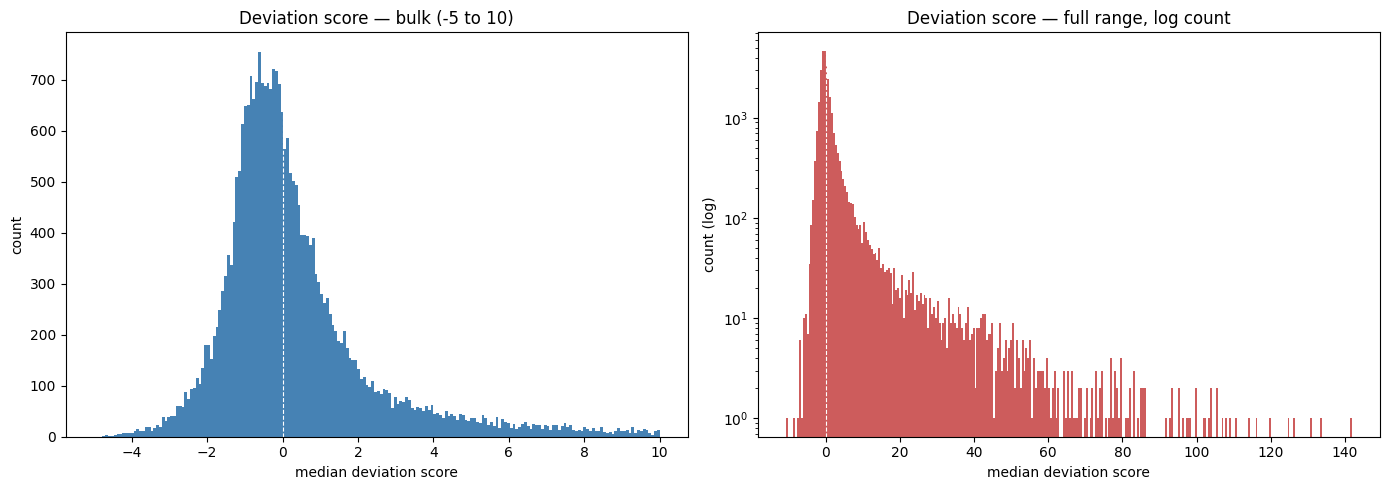

count    29396.000000
mean         1.782041
std          7.912195
min        -10.678899
25%         -0.857108
50%         -0.068472
75%          1.238736
max        141.816156
Name: median_deviation_score, dtype: float64
skew: 6.78 | kurtosis: 62.9
0.500    -0.07
0.900     4.81
0.950    10.88
0.975    22.17
0.990    41.06
0.999    92.28
Name: median_deviation_score, dtype: float64
share > 3: 14.36 %
share > 5: 9.72 %
max: 141.8
floored share: 0.0 %
floored share among score>5: 0.0 %


In [17]:
s = price_rolling_median['median_deviation_score'].dropna()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Left: the bulk — zoom to where normal hours live, linear y
ax[0].hist(s, bins=200, range=(-5, 10), color='steelblue', edgecolor='none')
ax[0].axvline(0, color='white', lw=0.8, ls='--')   # no-deviation line
ax[0].set_title('Deviation score — bulk (-5 to 10)')
ax[0].set_xlabel('median deviation score')
ax[0].set_ylabel('count')

# Right: full range, log y — so the spike tail is visible
ax[1].hist(s, bins=300, color='indianred', edgecolor='none')
ax[1].set_yscale('log')
ax[1].axvline(0, color='white', lw=0.8, ls='--')
ax[1].set_title('Deviation score — full range, log count')
ax[1].set_xlabel('median deviation score')
ax[1].set_ylabel('count (log)')

plt.tight_layout()
plt.show()

# quantify what the plot is showing
print(s.describe())
print("skew:", round(s.skew(), 2), "| kurtosis:", round(s.kurtosis(), 2))
print(s.quantile([.5, .9, .95, .975, .99, .999]).round(2))
print("share > 3:", round((s > 3).mean()*100, 2), "%")
print("share > 5:", round((s > 5).mean()*100, 2), "%")
print("max:", round(s.max(), 1))

floored = price_rolling_median['same_hour_30_obs_roll_MAD'] < 1.0
print("floored share:", round(floored.mean()*100, 2), "%")
print("floored share among score>5:", round(floored[price_rolling_median['median_deviation_score']>5].mean()*100, 2), "%")

In [8]:
from IPython.display import Markdown, display

q = s.quantile([.25, .75, .9, .95, .99])

para = (
    f"The bulk of the deviation score is centered near zero (median {s.median():.2f}), "
    f"but the mean sits at {s.mean():.2f}, showing the pull of the upper tail on the average. "
    f"The standard deviation is {s.std():.2f}, yet the middle 50% of scores span only about "
    f"{q[.25]:.2f} to {q[.75]:.2f}, far tighter than the std suggests. "
    f"This reflects that most hours sit close to their hour-of-day baseline; the std is inflated "
    f"by a thin set of extreme positive scores rather than describing a typical hour. "
    f"A skew of {s.skew():.2f} and kurtosis of {s.kurtosis():.2f} confirm a distribution that is "
    f"heavily right-skewed with a fat tail. The tail's reach is visible in the upper quantiles: "
    f"the 90th percentile is {q[.9]:.2f}, the 95th jumps to {q[.95]:.2f}, and the 99th to {q[.99]:.2f}."
)

display(Markdown(para))

The bulk of the deviation score is centered near zero (median -0.07), but the mean sits at 1.78, showing the pull of the upper tail on the average. The standard deviation is 7.91, yet the middle 50% of scores span only about -0.86 to 1.24, far tighter than the std suggests. This reflects that most hours sit close to their hour-of-day baseline; the std is inflated by a thin set of extreme positive scores rather than describing a typical hour. A skew of 6.78 and kurtosis of 62.90 confirm a distribution that is heavily right-skewed with a fat tail. The tail's reach is visible in the upper quantiles: the 90th percentile is 4.81, the 95th jumps to 10.88, and the 99th to 41.06.

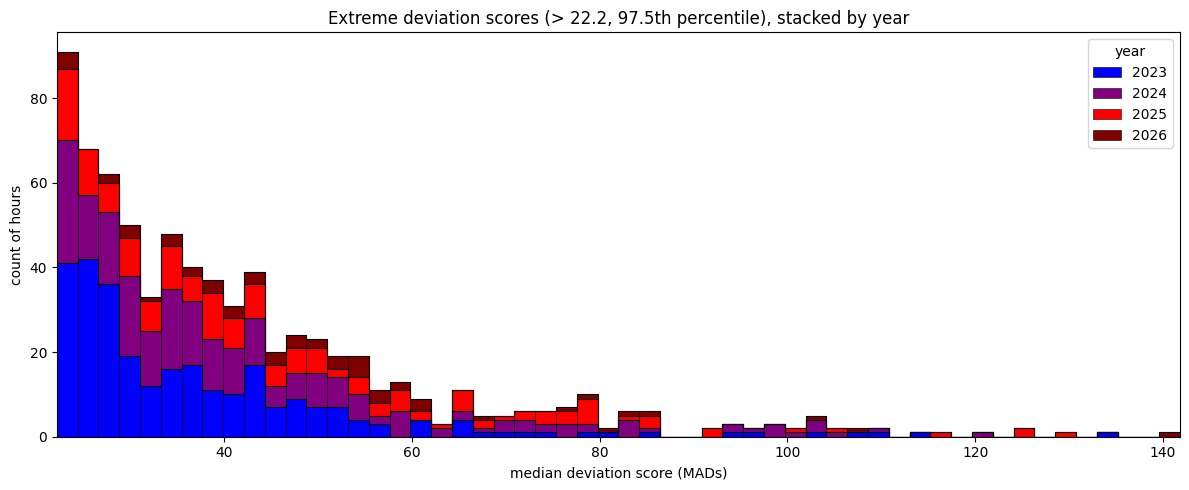

In [23]:
import matplotlib.pyplot as plt
import numpy as np

p975 = price_rolling_median['median_deviation_score'].quantile(0.975)

tail = price_rolling_median.loc[
    price_rolling_median['median_deviation_score'] > p975,
    ['date_he', 'median_deviation_score']
].copy()
tail['year']  = tail['date_he'].dt.year

lo, hi = tail['median_deviation_score'].min(), tail['median_deviation_score'].max()
bins = np.linspace(lo, hi, 55)

# --- year graph (only plot kept) ---
year_colors = {2023: 'blue', 2024: 'purple', 2025: 'red', 2026: 'maroon'}
years = sorted(tail['year'].unique())
data_by_year = [tail.loc[tail['year'] == y, 'median_deviation_score'].values for y in years]

fig, ax = plt.subplots(figsize=(12, 5))
counts_y, edges, _ = ax.hist(
    data_by_year, bins=bins, stacked=True,
    color=[year_colors[y] for y in years], label=[str(y) for y in years],
    edgecolor='black', linewidth=0.4
)
for row in np.atleast_2d(counts_y):
    ax.step(edges, np.append(row, row[-1]), where='post', color='black', lw=0.8)
ax.set_xlim(lo, hi)
ax.set_title(f'Extreme deviation scores (> {p975:.1f}, 97.5th percentile), stacked by year')
ax.set_xlabel('median deviation score (MADs)')
ax.set_ylabel('count of hours')
ax.legend(title='year')
plt.tight_layout()
plt.show()

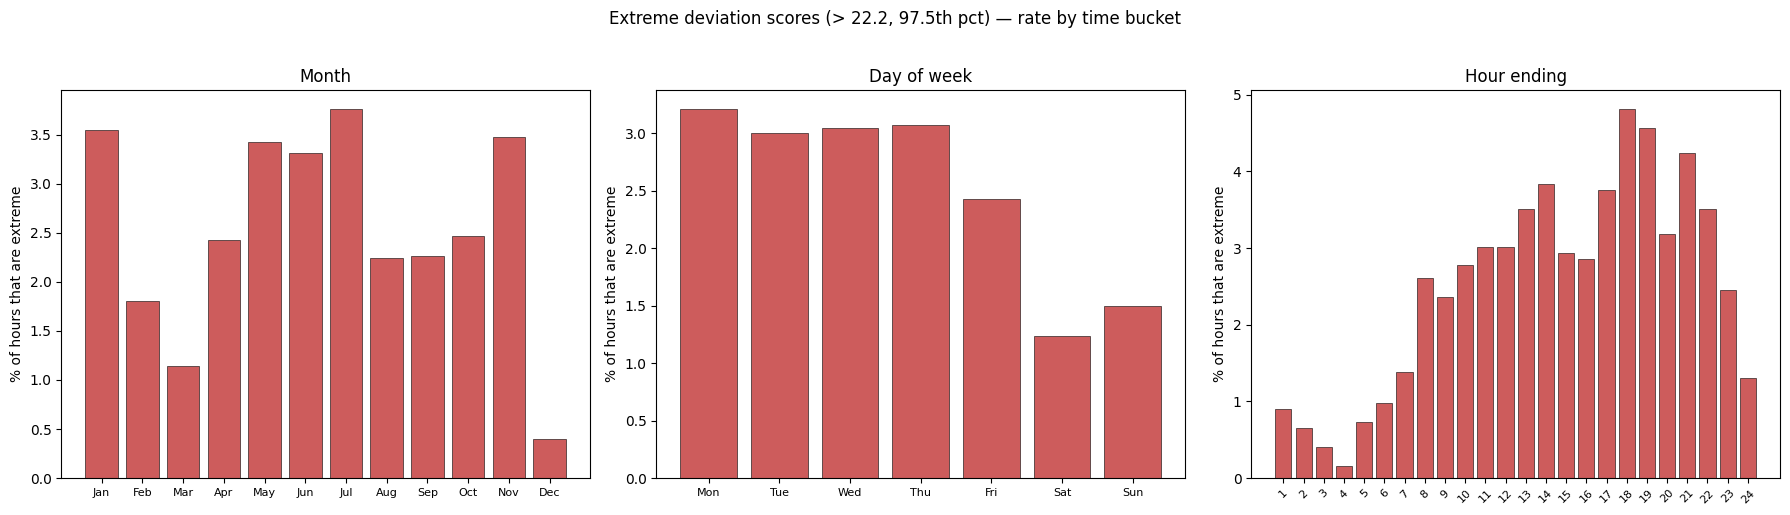

In [25]:
import matplotlib.pyplot as plt
import numpy as np

RATE = True   # True = extreme hours / total hours in bucket; False = raw counts

p975 = price_rolling_median['median_deviation_score'].quantile(0.975)
df = price_rolling_median.copy()
df['is_ext'] = df['median_deviation_score'] > p975

df['month'] = df['date_he'].dt.month
df['dow']   = df['date_he'].dt.dayofweek
df['he']    = df['date_he'].dt.hour.replace(0, 24)   # hour-ending: 0 -> 24

dims = [
    ('month', 'Month',       list(range(1, 13)),
        ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']),
    ('dow',   'Day of week', list(range(7)), ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']),
    ('he',    'Hour ending', list(range(1, 25)), None),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, title, order, labels) in zip(axes, dims):
    ext   = df.loc[df['is_ext'], col].value_counts().reindex(order, fill_value=0)
    total = df[col].value_counts().reindex(order, fill_value=0)
    y = (ext / total * 100) if RATE else ext
    ax.bar(range(len(order)), y.values, color='indianred', edgecolor='black', linewidth=0.4)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(labels if labels else order,
                       rotation=45 if col == 'he' else 0, fontsize=8)
    ax.set_title(title)
    ax.set_ylabel('% of hours that are extreme' if RATE else 'count of extreme hours')

fig.suptitle(f'Extreme deviation scores (> {p975:.1f}, 97.5th pct) — '
             f'{"rate" if RATE else "count"} by time bucket', y=1.02)
plt.tight_layout()
plt.show()